# Stats

Mean: 20.00
Median: 22
Mode: [23, 24]
Range: 15
Variance: 20.40
Standard Deviation: 4.52
Skewness: -0.90 (Positive = Right skewed, Negative = Left skewed)
Kurtosis: -0.39 (High = Peaked, Low = Flat)


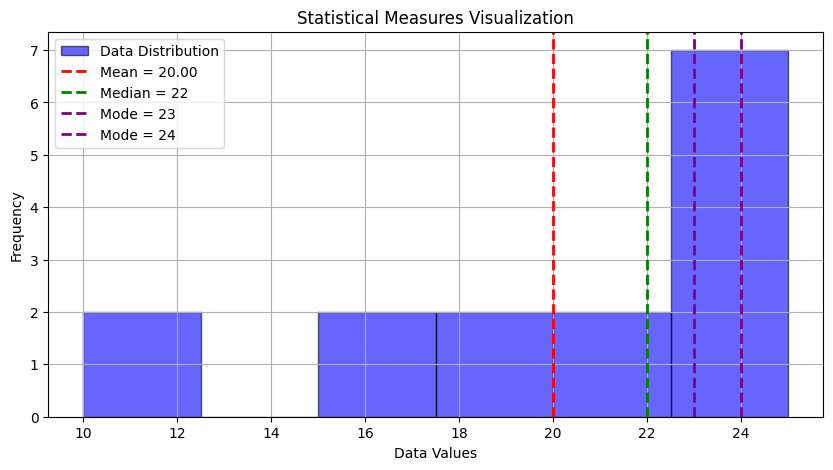

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from collections import Counter


# Mean (μ) - The average value
# Median - The middle value when sorted
# Mode - The most frequently occurring value
# Range - Difference between max and min values
# Variance (σ²) - Spread of data around mean
# Standard Deviation (σ) - Square root of variance
# Skewness -  Measure of data symmetry (Measures asymmetry)
# Kurtosis - Measures peakness of distribution


# Physical meaning
# Mean (μ)	- Balance point	 - Average height, average temperature
# Variance (σ²) - 	Spread of values	- Small variance = similar heights, large variance = very different heights
# Standard Deviation (σ)	- Typical distance from mean	- How consistent students' grades are
# Range	- Total spread	- Temperature difference between hottest & coldest day
# Skewness	- Direction of imbalance	- Right-skewed income (few rich people), left-skewed test scores (few low scores)
# Kurtosis	- Sharpness of peak	- High kurtosis = extreme changes (stocks), low kurtosis = normal heights


# Sample data
data = [10, 12, 23, 23, 16, 23, 21, 16, 18, 19, 24, 22, 24, 24, 25]

# Function to calculate mean
def mean(data):
    return sum(data) / len(data)

# Function to calculate median
def median(data):
    sorted_data = sorted(data)
    n = len(sorted_data)
    mid = n // 2
    if n % 2 == 0:
        return (sorted_data[mid - 1] + sorted_data[mid]) / 2
    else:
        return sorted_data[mid]

# Function to calculate mode
def mode(data):
    count = Counter(data)
    max_count = max(count.values())
    return [k for k, v in count.items() if v == max_count]

# Function to calculate range
def data_range(data):
    return max(data) - min(data)

# Function to calculate variance
def variance(data, mu):
    return sum((x - mu) ** 2 for x in data) / len(data)

# Function to calculate standard deviation
def standard_deviation(var):
    return var ** 0.5

# Compute statistics
mu = mean(data)
med = median(data)
mod = mode(data)
r = data_range(data)
var = variance(data, mu)
std_dev = standard_deviation(var)
skewness = stats.skew(data)
kurt = stats.kurtosis(data)

# Print values
print(f"Mean: {mu:.2f}")
print(f"Median: {med}")
print(f"Mode: {mod}")
print(f"Range: {r}")
print(f"Variance: {var:.2f}")
print(f"Standard Deviation: {std_dev:.2f}")
print(f"Skewness: {skewness:.2f} (Positive = Right skewed, Negative = Left skewed)")
print(f"Kurtosis: {kurt:.2f} (High = Peaked, Low = Flat)")

# Visualization
plt.figure(figsize=(10, 5))
plt.hist(data, bins=6, alpha=0.6, color='b', edgecolor='black', label="Data Distribution")
plt.axvline(mu, color='red', linestyle='dashed', linewidth=2, label=f"Mean = {mu:.2f}")
plt.axvline(med, color='green', linestyle='dashed', linewidth=2, label=f"Median = {med}")
for m in mod:
    plt.axvline(m, color='purple', linestyle='dashed', linewidth=2, label=f"Mode = {m}")
plt.xlabel("Data Values")
plt.ylabel("Frequency")
plt.title("Statistical Measures Visualization")
plt.legend()
plt.grid()
plt.show()


# The sample mean is an unbiased estimator of the population mean.

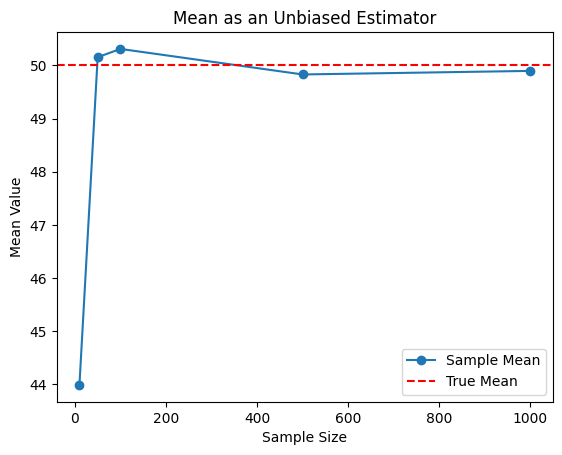

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# True population mean
true_mean = 50

# Generate 1000 random samples from a normal distribution
sample_sizes = [10, 50, 100, 500, 1000]
means = []

for size in sample_sizes:
    sample = np.random.normal(loc=true_mean, scale=10, size=size)  # Normal distribution
    sample_mean = np.mean(sample)
    means.append(sample_mean)

# Plot sample means vs. true mean
plt.plot(sample_sizes, means, marker='o', linestyle='-', label="Sample Mean")
plt.axhline(true_mean, color='r', linestyle='dashed', label="True Mean")
plt.xlabel("Sample Size")
plt.ylabel("Mean Value")
plt.title("Mean as an Unbiased Estimator")
plt.legend()
plt.show()

# As the sample size increases, the sample mean gets closer to the true population mean.
# This shows the mean is an unbiased estimator.


# Mean Has the Lowest Variance

#compare the variance of the mean to the variance of the median.

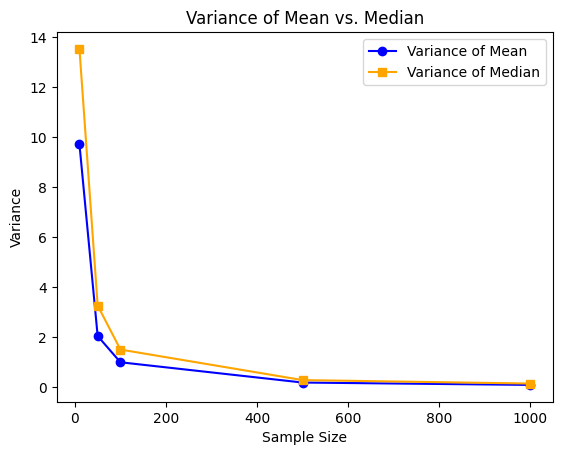

In [6]:
sample_sizes = [10, 50, 100, 500, 1000]
mean_vars = []
median_vars = []

for size in sample_sizes:
    samples = [np.random.normal(50, 10, size) for _ in range(1000)]  # Generate 1000 samples
    mean_var = np.var([np.mean(sample) for sample in samples])
    median_var = np.var([np.median(sample) for sample in samples])
    mean_vars.append(mean_var)
    median_vars.append(median_var)

# Plot variance of mean vs. median
plt.plot(sample_sizes, mean_vars, marker='o', label="Variance of Mean", color='blue')
plt.plot(sample_sizes, median_vars, marker='s', label="Variance of Median", color='orange')
plt.xlabel("Sample Size")
plt.ylabel("Variance")
plt.title("Variance of Mean vs. Median")
plt.legend()
plt.show()

# The mean has lower variance than the median.
# This means the mean is more precise than the median, making it a better estimator.


# When the Mean Fails – Effect of Outliers

Normal Data Mean: 19.00, Median: 19.00
Outlier Data Mean: 36.20, Median: 19.00


/tmp/ipykernel_842009/2607310245.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data, data_outlier], labels=["Normal Data", "With Outlier"])


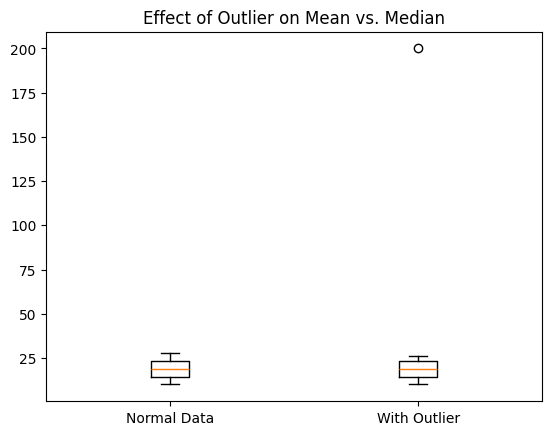

In [7]:
# Data with no outliers
data = [10, 12, 14, 16, 18, 20, 22, 24, 26, 28]

# Data with an outlier
data_outlier = [10, 12, 14, 16, 18, 20, 22, 24, 26, 200]  # 200 is an extreme outlier

# Calculate mean and median
mean_normal = np.mean(data)
median_normal = np.median(data)

mean_outlier = np.mean(data_outlier)
median_outlier = np.median(data_outlier)

print(f"Normal Data Mean: {mean_normal:.2f}, Median: {median_normal:.2f}")
print(f"Outlier Data Mean: {mean_outlier:.2f}, Median: {median_outlier:.2f}")

# Plot
plt.boxplot([data, data_outlier], labels=["Normal Data", "With Outlier"])
plt.title("Effect of Outlier on Mean vs. Median")
plt.show()

# The mean increases drastically due to the outlier (200).
# The median remains stable, showing it is a better choice in skewed data.


# The Mean is Consistent (Law of Large Numbers)

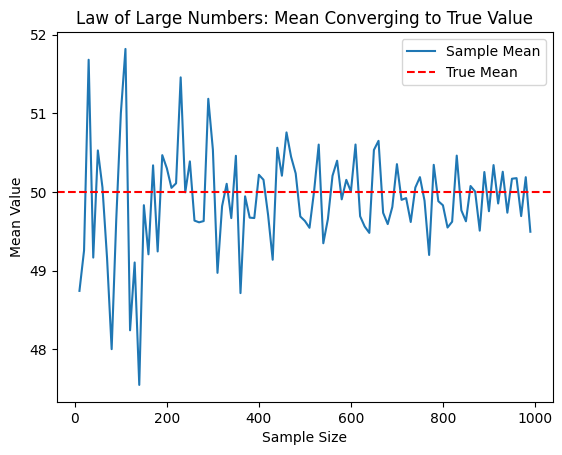

In [9]:
#The more samples we take, the closer the mean gets to the true value.
true_mean = 50
sample_sizes = np.arange(10, 1000, 10)
estimates = []

for size in sample_sizes:
    sample = np.random.normal(loc=true_mean, scale=10, size=size)
    estimates.append(np.mean(sample))

plt.plot(sample_sizes, estimates, label="Sample Mean")
plt.axhline(true_mean, color='r', linestyle='dashed', label="True Mean")
plt.xlabel("Sample Size")
plt.ylabel("Mean Value")
plt.title("Law of Large Numbers: Mean Converging to True Value")
plt.legend()
plt.show()

# As the sample size increases, the mean stabilizes around the true mean.
# This shows the mean is a consistent estimator.


Mean Salary: $157.78K
Median Salary: $55.00K


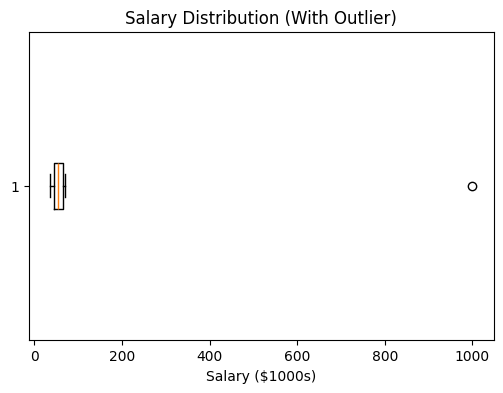

In [10]:
# should we use mean or median

#  A company wants to know the average employee salary. Should they use the mean or median?

import numpy as np
import matplotlib.pyplot as plt

# Simulating salaries of employees (in $1000s)
salaries = [35, 40, 45, 50, 55, 60, 65, 70, 1000]  # 1000 is an outlier (CEO salary)

# Calculate mean and median
mean_salary = np.mean(salaries)
median_salary = np.median(salaries)

print(f"Mean Salary: ${mean_salary:.2f}K")
print(f"Median Salary: ${median_salary:.2f}K")

# Plot salaries
plt.figure(figsize=(6, 4))
plt.boxplot(salaries, vert=False)
plt.title("Salary Distribution (With Outlier)")
plt.xlabel("Salary ($1000s)")
plt.show()


Mean House Price: $807.78K
Median House Price: $300.00K


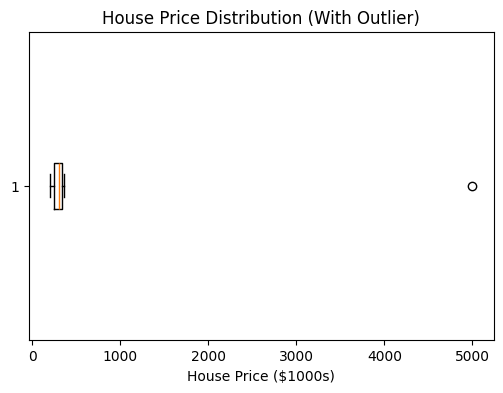

In [11]:
#  A real estate agent wants to calculate the average house price in a city.

house_prices = [200, 220, 250, 280, 300, 320, 340, 360, 5000]  # 5000 is an outlier (luxury mansion)

# Mean vs. Median
mean_price = np.mean(house_prices)
median_price = np.median(house_prices)

print(f"Mean House Price: ${mean_price:.2f}K")
print(f"Median House Price: ${median_price:.2f}K")

# Plot house prices
plt.figure(figsize=(6, 4))
plt.boxplot(house_prices, vert=False)
plt.title("House Price Distribution (With Outlier)")
plt.xlabel("House Price ($1000s)")
plt.show()


Mean Test Score: 73.00
Median Test Score: 72.50


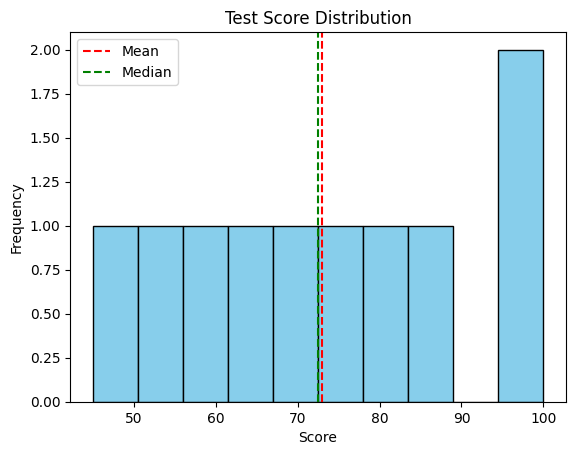

In [12]:
# A teacher wants to report the average test score for a class of students.

# Simulating student test scores (out of 100)
scores = [45, 55, 60, 65, 70, 75, 80, 85, 95, 100]

# Mean vs. Median
mean_score = np.mean(scores)
median_score = np.median(scores)

print(f"Mean Test Score: {mean_score:.2f}")
print(f"Median Test Score: {median_score:.2f}")

# Plot test scores
plt.hist(scores, bins=10, color='skyblue', edgecolor='black')
plt.axvline(mean_score, color='red', linestyle='dashed', label="Mean")
plt.axvline(median_score, color='green', linestyle='dashed', label="Median")
plt.title("Test Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()


# The mean is the best estimator when data is symmetrical and has no extreme values.
# When dealing with skewed distributions or outliers, the median is better.
# Always visualize your data before choosing the best estimator!